In [1]:
!pip install git+https://github.com/adil1828/GW_JAX_TEAM_Nested

  Cloning https://github.com/adil1828/GW_JAX_TEAM_Nested to /tmp/pip-req-build-1aixr1qa
  Running command git clone --filter=blob:none --quiet https://github.com/adil1828/GW_JAX_TEAM_Nested /tmp/pip-req-build-1aixr1qa
  Resolved https://github.com/adil1828/GW_JAX_TEAM_Nested to commit 8ae26f8ca3030cc92d9342685389714907ca7a94
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.0/214.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.9/92.9 kB 11.

In [2]:
import time
#from pathlib import Path

In [3]:
"""GW150914 analysis with the BlackJAX NS-AW nested sampler."""

'GW150914 analysis with the BlackJAX NS-AW nested sampler.'

In [4]:
import corner
import numpy as np
import jax
import jax.numpy as jnp

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


In [5]:
jax.config.update("jax_enable_x64", True)

In [6]:
!pip install --upgrade "jax[cuda]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2
    Uninstalling jax-cuda12-plugin-0.7.2:
      Successfully uninstalled jax-cuda12-plugin-0.7.2


In [7]:
from jimgw.core.jim import Jim
from jimgw.core.prior import (
    CombinePrior,
    UniformPrior,
    CosinePrior,
    SinePrior,
    PowerLawPrior,
)
from jimgw.core.prior import GaussianPrior, StandardNormalDistribution
from jimgw.core.single_event.detector import get_ET, get_CE
from jimgw.core.single_event.likelihood import TransientLikelihoodFD,HeterodynedTransientLikelihoodFD
from jimgw.core.single_event.data import Data
from jimgw.core.single_event.waveform import RippleIMRPhenomXAS,RippleIMRPhenomXPHM,RippleIMRPhenomD,RippleIMRPhenomD_NRTidalv2


from jimgw.core.single_event.transforms import (
    MassRatioToSymmetricMassRatioTransform,
    GeocentricArrivalTimeToDetectorArrivalTimeTransform,
    SkyFrameToDetectorFrameSkyPositionTransform,
)
from jimgw.core.transforms import (
    BoundToBound,
    CosineTransform,
    PowerLawTransform,
    reverse_bijective_transform,
)
from jimgw.samplers.config import BlackJAXNSAWConfig

ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 508, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 381, in initialize
    cuda_plugin_extension.register_custom_type, c_api
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jax_cuda12_plugin.cuda_plugin_extension' has no attribute 'register_custom_type'. Did you mean: 'register_custom_type_id'?


In [8]:
import jimgw
import inspect

print("jimgw version :", jimgw.__version__)
print("jimgw location:", inspect.getfile(jimgw))

jimgw version : 0.0.1.dev5
jimgw location: /usr/local/lib/python3.12/dist-packages/jimgw/__init__.py


In [9]:
import blackjax
import inspect

print("blackjax version :", blackjax.__version__)
print("blackjax location:", inspect.getfile(blackjax))

blackjax version : 1.6
blackjax location: /usr/local/lib/python3.12/dist-packages/blackjax/__init__.py


In [10]:
import anesthetic
import inspect

print("anesthetic version :", anesthetic.__version__)
print("anesthetic location:", inspect.getfile(anesthetic))

anesthetic version : 2.14.9
anesthetic location: /usr/local/lib/python3.12/dist-packages/anesthetic/__init__.py


In [11]:
import sys, pkg_resources

packages = [
    "jax", "jaxlib",
    "jax-cuda12-plugin", "jax-cuda12-pjrt",
    "blackjax", "anesthetic", "jimgw",
    "numpy", "scipy"
]

for p in packages:
    try:
        dist = pkg_resources.get_distribution(p)
        print(f"{p}=={dist.version}")
    except Exception:
        print(f"{p}: NOT INSTALLED")

jax==0.10.2
jaxlib==0.10.2
jax-cuda12-plugin==0.10.2
jax-cuda12-pjrt==0.10.2
blackjax==1.6
anesthetic==2.14.9
jimgw==0.0.1.dev5
numpy==2.0.2
scipy==1.18.0


/tmp/ipykernel_1364/4177245185.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import sys, pkg_resources


In [12]:
!pip uninstall -y blackjax
!pip install -U "blackjax @ git+https://github.com/blackjax-devs/blackjax.git"

Found existing installation: blackjax 1.6
Uninstalling blackjax-1.6:
  Successfully uninstalled blackjax-1.6
  Cloning https://github.com/blackjax-devs/blackjax.git to /tmp/pip-install-n05irr3v/blackjax_3a915d40ad3a4ee394d9171a16b2c648
  Running command git clone --filter=blob:none --quiet https://github.com/blackjax-devs/blackjax.git /tmp/pip-install-n05irr3v/blackjax_3a915d40ad3a4ee394d9171a16b2c648
  Resolved https://github.com/blackjax-devs/blackjax.git to commit 44eac39e708e7fd4b36658416260d13ab32b1681
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for blackjax: filename=blackjax-1.7.dev4+g44eac39e7-py3-none-any.whl size=4869815 sha256=26372d28b7cb19e1e74574aa4c0dce52a069b864b92bf38efb17b7339c71ddb5
  Stored in directory: /tmp/pip-ephem-wheel-cache-h3r0amnm/wheels/bc/8f/c3/b14be13ef107ea18dd389d9bd1745278ceee5a6768d4c8317d
Successfully built blackjax


In [13]:
import jax, jaxlib, blackjax
print("jax", jax.__version__)
print("jaxlib", jaxlib.__version__)
print("blackjax", blackjax.__version__)
print(jax.devices())

jax 0.10.2
jaxlib 0.10.2
blackjax 1.6
[CudaDevice(id=0)]


In [14]:
import blackjax

print(blackjax.__version__)
print(hasattr(blackjax, "ns"))


1.6
True


In [15]:
from jimgw.core.single_event.detector import GroundBased2G
from jimgw.core.constants import DEG_TO_RAD

def get_CE2() -> GroundBased2G:
    """Second Cosmic Explorer facility, at the LIGO Livingston site geometry
    (verified against get_L1() in detector.py) -- the standard placeholder
    convention (one CE per existing LIGO site) used in CE forecasting studies."""
    return GroundBased2G(
        "CE2",
        latitude=(30 + 33.0 / 60 + 46.4196 / 3600) * DEG_TO_RAD,
        longitude=-(90 + 46.0 / 60 + 27.2654 / 3600) * DEG_TO_RAD,
        xarm_azimuth=197.7165 * DEG_TO_RAD,
        yarm_azimuth=287.7165 * DEG_TO_RAD,
        xarm_tilt=-3.121e-4,
        yarm_tilt=-6.107e-4,
        elevation=-6.574,
        modes="pc",
    )



In [16]:
# q_inj = 0.8
# eta_inj = q_inj / (1.0 + q_inj)**2

inj_params = {
    "M_c": 1.1976232319088198,
    "eta": 0.24691358024691357,

    "s1_z": 0.028327,
    "s2_z": 0.013249,

    "d_L": 42.0,
   "lambda_1": 391.0560048763879,   # m1 = 1.54
   "lambda_2": 1383.665429681563,   # m2 = 1.232
    "t_c": -2.36e-4,
    "phase_c": 2.0,

    "iota": 2.8495,
    "psi": 0.70,

   "ra": 3.4396,
    "dec": -0.3998,
}


In [17]:
# Injection GPS time; choose arbitrary fixed time
gps = 1187008882.43

# M_c ~ 1.2 Msun needs ~160s in-band from fmin=20Hz -- too long for a fast NS
# check. Raising fmin to 40Hz shortens the chirp to ~25.6s, which fits inside
# a 32s window (duration - post_trigger_duration = 30s available), giving
# ~15% margin so the injected data stays self-consistent with the window.
duration = 8192.0
post_trigger_duration = 2.0
start = gps + post_trigger_duration - duration
end = start + duration

psd_duration = 2048.0
psd_start = start - psd_duration
psd_end = start

fmin = 5.0
fmax = 2048.0

ifos = [get_CE(), get_CE2()] + get_ET()



In [18]:
waveform = RippleIMRPhenomD_NRTidalv2(f_ref=fmin, use_lambda_tildes=False)
sampling_frequency = 2*fmax

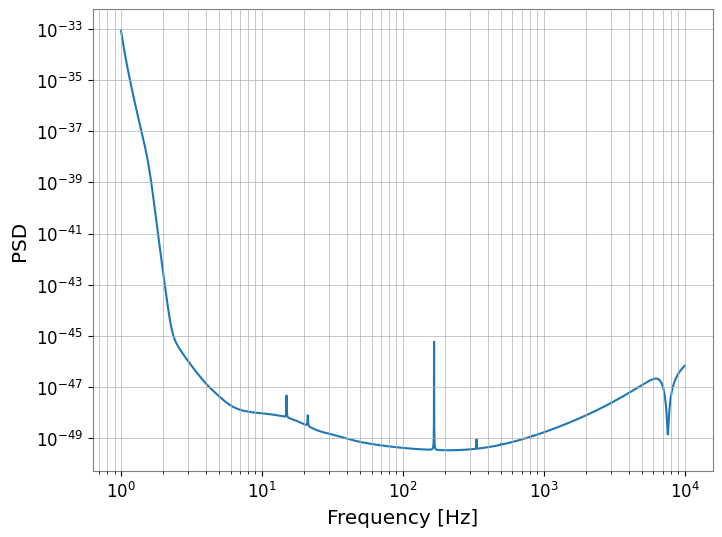

In [19]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("18213_ET20kmcolumns.txt")

plt.figure(figsize=(8,6))
plt.loglog(data[:,0], data[:,-1])

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True, which="both")
plt.show()

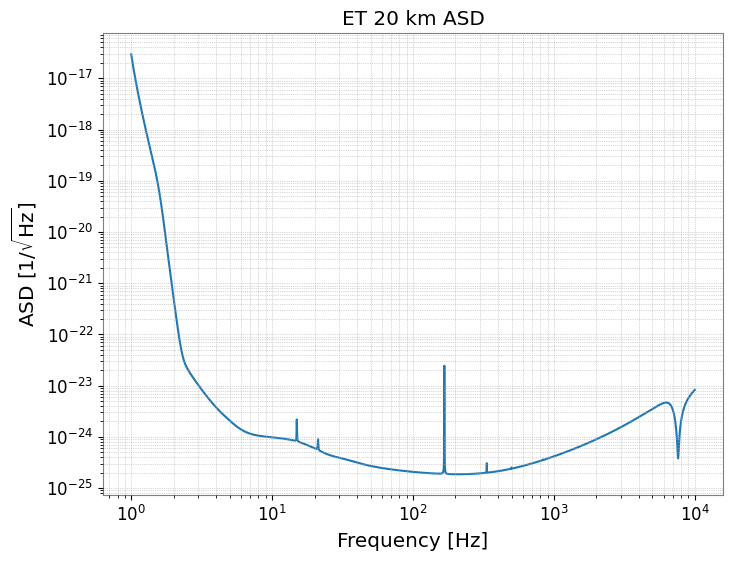

In [20]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("18213_ET20kmcolumns.txt")

freq = data[:,0]
psd  = data[:,-1]      # last column
asd  = np.sqrt(psd)

plt.figure(figsize=(8,6))
plt.loglog(freq, asd)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [$1/\sqrt{\mathrm{Hz}}$]")
plt.title("ET 20 km ASD")
plt.grid(True, which="both", ls=":")
plt.show()

In [21]:
import numpy as np

data = np.loadtxt("18213_ET20kmcolumns.txt")

freq = data[:,0]
psd  = data[:,3]

asd = np.sqrt(psd)

np.savetxt(
    "ET20km_ASD.txt",
    np.column_stack([freq, asd])
)

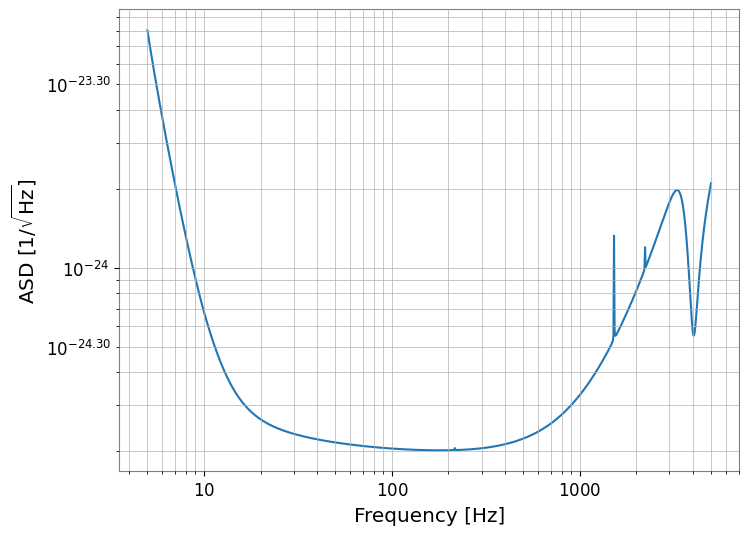

In [22]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("CE40km_ASD.txt")

plt.figure(figsize=(8,6))
plt.loglog(data[:,0], data[:,-1])

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [$1/\sqrt{\mathrm{Hz}}$]")
plt.grid(True, which="both")
plt.show()

In [23]:
CE_NAMES = {"CE", "CE2"}   # confirm CE2's .name matches whatever your get_CE2() sets it to
ET_NAMES = {"ET1", "ET2", "ET3"}

for ifo in ifos:
    if ifo.name in CE_NAMES:
        asd_file = "CE40km_ASD.txt"       # whichever CE curve you've been using
    elif ifo.name in ET_NAMES:
        asd_file = "ET20km_ASD.txt"       # the ET curve from this session
    else:
        raise ValueError(f"no ASD mapped for {ifo.name}")
    ifo.load_and_set_psd(asd_file=asd_file)
    ifo.inject_signal(
        duration, sampling_frequency, trigger_time=gps,
        waveform_model=waveform, parameters=inj_params,
        f_min=fmin, f_max=fmax, zero_noise=True,
    )

INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.430 s.
INFO | jimgw.core.single_event.data | Computing FFT of CE_empty data
INFO | jimgw.core.single_event.detector | For detector CE, the injected signal has:
INFO | jimgw.core.single_event.detector |   - Optimal SNR: 2383.6964
INFO | jimgw.core.single_event.detector |   - Match filtered SNR: 2383.6964+0.0000j
INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.430 s.
INFO | jimgw.core.single_event.data | Computing FFT of CE2_empty data
INFO | jimgw.core.single_event.detector | For detector CE2, the injected signal has:
INFO | jimgw.core.single_event.detector |   - Optimal SNR: 2010.9785
INFO | jimgw.core.single_event.detector |   - Match filtered SNR: 2010.9785+0.0000j
INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.

In [24]:

# for ifo in ifos:
#     ifo.load_and_set_psd(asd_file="ET20km_ASD.txt")
#     ifo.inject_signal(
#         duration,
#         sampling_frequency,
#         trigger_time=gps,
#         waveform_model=waveform,
#         parameters=inj_params,
#         f_min=fmin,
#         f_max=fmax,
#         zero_noise=True,
#     )

In [25]:
# import inspect
# print(inspect.signature(ifos[0].load_and_set_psd))
# print(inspect.getsource(type(ifos[0]).load_and_set_psd))

In [26]:
for ifo in ifos:
    print("\n", ifo.name)
    print(dir(ifo.data))


 CE
['__abstractmethods__', '__annotations__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_from_gwf', 'delta_t', 'duration', 'fd', 'fft', 'frequencies', 'frequency_slice', 'from_fd', 'from_file', 'from_gwosc', 'has_fd', 'is_empty', 'n_freq', 'n_time', 'name', 'sampling_frequency', 'set_tukey_window', 'start_time', 'td', 'times', 'to_file', 'to_psd', 'window']

 CE2
['__abstractmethods__', '__annotations__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__'

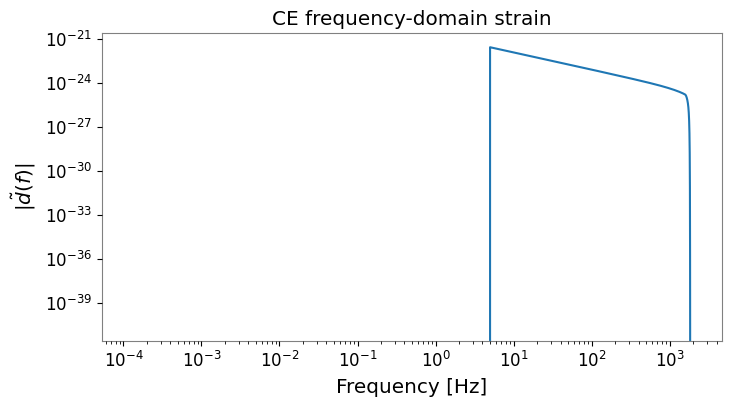

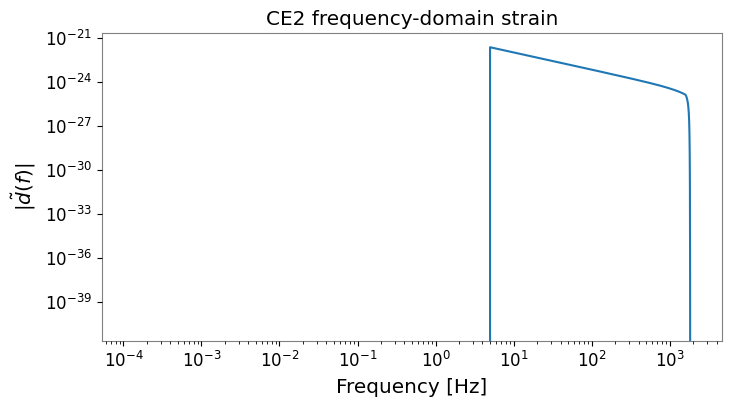

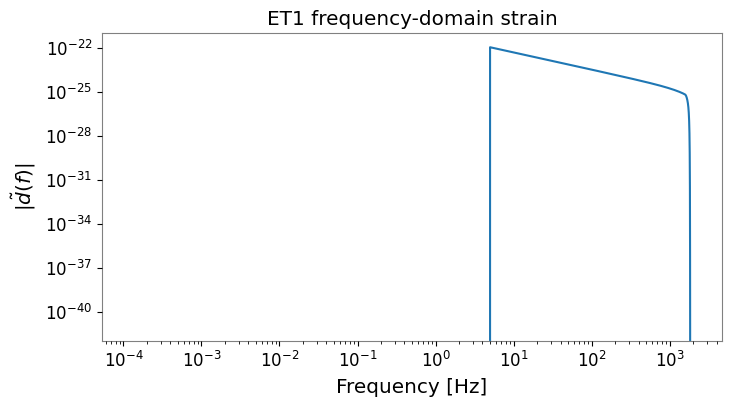

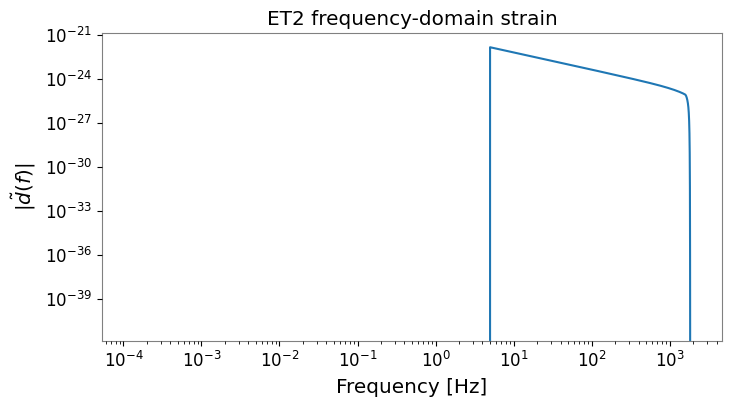

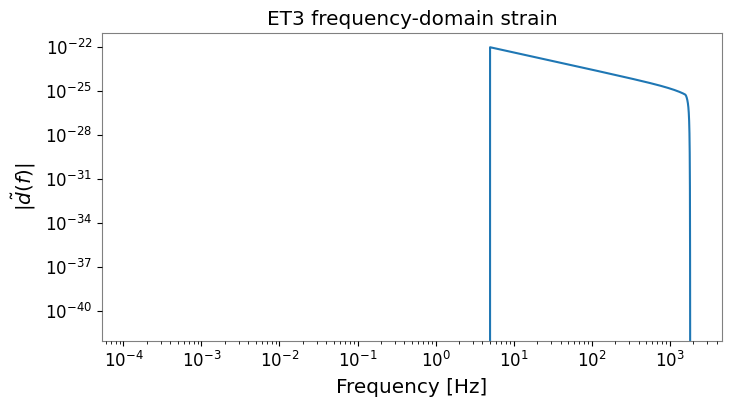

In [27]:
import matplotlib.pyplot as plt
for ifo in ifos:
    plt.figure(figsize=(8, 4))
    plt.loglog(ifo.data.frequencies, np.abs(ifo.data.fd))
    plt.title(f"{ifo.name} frequency-domain strain")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(r"$|\tilde{d}(f)|$")
    plt.grid()
    plt.show()

--- Waveform model ---

--- Prior ---

In [28]:
M_c_min, M_c_max = 1.18, 1.21
q_min, q_max = 0.5, 1.0

#d_L_min, d_L_max = 30.0, 50.0
#t_det_min, t_det_max = -0.001, 0.001
t_c_min, t_c_max = -0.001, 0.001

s1_z_min, s1_z_max = -0.05, 0.05
s2_z_min, s2_z_max = -0.05, 0.05

dL_mu, dL_sigma = 42.0, 3.0      # adjust to your intended constraint width
iota_mu, iota_sigma = 2.8495, 0.03   # see note on sigma below


prior = CombinePrior(
    [
        UniformPrior(M_c_min, M_c_max, parameter_names=["M_c"]),
        UniformPrior(q_min, q_max, parameter_names=["q"]),

        UniformPrior(s1_z_min, s1_z_max, parameter_names=["s1_z"]),
        UniformPrior(s2_z_min, s2_z_max, parameter_names=["s2_z"]),

        #SinePrior(parameter_names=["iota"]),
         #PowerLawPrior(d_L_min, d_L_max, 2.0, parameter_names=["d_L"]),
        GaussianPrior(dL_mu, dL_sigma, parameter_names=["d_L"]),
        GaussianPrior(iota_mu, iota_sigma, parameter_names=["iota"]),
         #UniformPrior(t_det_min, t_det_max, parameter_names=["t_det"]),
        UniformPrior(t_c_min, t_c_max, parameter_names=["t_c"]),
        UniformPrior(0.0, jnp.pi, parameter_names=["psi"]),
        # UniformPrior(0.0, 2 * jnp.pi, parameter_names=["ra"]),
        # CosinePrior(parameter_names=["dec"]),

        UniformPrior(0.0, 2 * jnp.pi, parameter_names=["phase_c"]),
    ]
)

In [29]:
prior

Combine(priors=(UniformPrior(xmin=1.18, xmax=1.21, parameter_names=('M_c',)), UniformPrior(xmin=0.5, xmax=1.0, parameter_names=('q',)), UniformPrior(xmin=-0.05, xmax=0.05, parameter_names=('s1_z',)), UniformPrior(xmin=-0.05, xmax=0.05, parameter_names=('s2_z',)), GaussianPrior(mu=42.0, sigma=3.0, parameter_names=('d_L',)), GaussianPrior(mu=2.8495, sigma=0.03, parameter_names=('iota',)), UniformPrior(xmin=-0.001, xmax=0.001, parameter_names=('t_c',)), UniformPrior(xmin=0.0, xmax=3.141592653589793, parameter_names=('psi',)), UniformPrior(xmin=0.0, xmax=6.283185307179586, parameter_names=('phase_c',))), parameter_names=('M_c', 'q', 's1_z', 's2_z', 'd_L', 'iota', 't_c', 'psi', 'phase_c'))

In [30]:
# !pip install --upgrade equinox

In [31]:
import jax.numpy as jnp
from jimgw.core.transforms import BijectiveTransform
from jax.scipy.special import erf, erfinv

def norm_cdf(z):
    return 0.5 * (1 + erf(z / jnp.sqrt(2)))

def norm_ppf(p):
    return jnp.sqrt(2) * erfinv(2 * p - 1)

class GaussianQuantileTransform(BijectiveTransform):
    """Natural direction: unit cube -> Gaussian(mu, sigma), same convention as PowerLawTransform."""
    def __init__(self, name_mapping, mu, sigma):
        super().__init__(name_mapping)
        self.mu = mu
        self.sigma = sigma
        self.transform_func = self._forward
        self.inverse_transform_func = self._inverse

    def _forward(self, params):
        # unit-cube -> physical
        u = params[self.name_mapping[0][0]]
        x = self.mu + self.sigma * norm_ppf(u)
        return {self.name_mapping[1][0]: x}

    def _inverse(self, params):
        # physical -> unit-cube
        x = params[self.name_mapping[1][0]]
        u = norm_cdf((x - self.mu) / self.sigma)
        return {self.name_mapping[0][0]: u}

--- Transforms ---

Each parameter is mapped to [0, 1].  Transform patterns:
  Uniform [a, b]           → BoundToBound([a, b] → [0, 1])
  SinePrior  [0, π]        → CosineTransform → BoundToBound([-1, 1] → [0, 1])
  PowerLawPrior (α=2)      → reverse_bijective_transform(PowerLawTransform)

In [32]:
sample_transforms = [
    # SkyFrameToDetectorFrameSkyPositionTransform(trigger_time=gps, ifos=ifos),

    BoundToBound(
        name_mapping=(["M_c"], ["M_c_unit"]),
        original_lower_bound=M_c_min,
        original_upper_bound=M_c_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["q"], ["q_unit"]),
        original_lower_bound=q_min,
        original_upper_bound=q_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["s1_z"], ["s1_z_unit"]),
        original_lower_bound=s1_z_min,
        original_upper_bound=s1_z_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["s2_z"], ["s2_z_unit"]),
        original_lower_bound=s2_z_min,
        original_upper_bound=s2_z_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
    reverse_bijective_transform(GaussianQuantileTransform(name_mapping=(["d_L_unit"], ["d_L"]), mu=dL_mu, sigma=dL_sigma)),
    reverse_bijective_transform(GaussianQuantileTransform(name_mapping=(["iota_unit"], ["iota"]), mu=iota_mu, sigma=iota_sigma)),
    # CosineTransform(name_mapping=(["iota"], ["cos_iota"])),

    # BoundToBound(
    #     name_mapping=(["cos_iota"], ["cos_iota_unit"]),
    #     original_lower_bound=-1.0,
    #     original_upper_bound=1.0,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),

    # reverse_bijective_transform(
    #     PowerLawTransform(
    #         name_mapping=(["d_L_unit"], ["d_L"]),
    #         xmin=d_L_min,
    #         xmax=d_L_max,
    #         alpha=2.0,
    #     )
    # ),

    # BoundToBound(
    #     name_mapping=(["t_det"], ["t_det_unit"]),
    #     original_lower_bound=t_det_min,
    #     original_upper_bound=t_det_max,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,

    # ),
    #
    BoundToBound(name_mapping=(["t_c"], ["t_c_unit"]),
                 original_lower_bound=t_c_min,
                 original_upper_bound=t_c_max,
                 target_lower_bound=0.0,
                 target_upper_bound=1.0),
    BoundToBound(
        name_mapping=(["psi"], ["psi_unit"]),
        original_lower_bound=0.0,
        original_upper_bound=jnp.pi,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
    BoundToBound(
        name_mapping=(["phase_c"], ["phase_c_unit"]),
        original_lower_bound=0.0,
        original_upper_bound=2*jnp.pi,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),


    # BoundToBound(
    #     name_mapping=(["azimuth"], ["azimuth_unit"]),
    #     original_lower_bound=0.0,
    #     original_upper_bound=2 * jnp.pi,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),

    # CosineTransform(name_mapping=(["zenith"], ["cos_zenith"])),

    # BoundToBound(
    #     name_mapping=(["cos_zenith"], ["cos_zenith_unit"]),
    #     original_lower_bound=-1.0,
    #     original_upper_bound=1.0,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),
]

In [33]:

dd2_table = np.loadtxt('SFHo_mass_lambda.txt')  # header line auto-skipped (starts with #)
dd2_m_grid = jnp.array(dd2_table[:, 0])
dd2_lambda_grid = jnp.array(dd2_table[:, 1])

print("table mass range:", dd2_m_grid.min(), "-", dd2_m_grid.max())  # should print ~0.345 - 2.3845

table mass range: 0.30317910923 - 2.0135394204


In [34]:

from jimgw.core.transforms import NtoMTransform

class EOSMcEtaToLambdaTransform(NtoMTransform):
    def __init__(self, name_mapping, m_grid, lambda_grid):
        super().__init__(name_mapping)
        self.m_grid, self.lambda_grid = m_grid, lambda_grid
    def transform_func(self, x):
        Mc, eta = x["M_c"], x["eta"]
        M = Mc / eta**0.6
        root = jnp.sqrt(jnp.clip(1.0 - 4.0*eta, 0.0, None))
        m1 = 0.5*M*(1.0+root); m2 = 0.5*M*(1.0-root)
        return {
            "M_c": Mc, "eta": eta,   # pass through — don't let them get consumed
            "lambda_1": jnp.interp(m1, self.m_grid, self.lambda_grid),
            "lambda_2": jnp.interp(m2, self.m_grid, self.lambda_grid),
        }

eos_transform_dd2 = EOSMcEtaToLambdaTransform(
    (["M_c", "eta"], ["M_c", "eta", "lambda_1", "lambda_2"]),   # <- outputs include M_c, eta now
    dd2_m_grid, dd2_lambda_grid
)

In [35]:
test_params = {"M_c": jnp.array(1.1976232319088198), "eta": jnp.array(0.24691358024691357)}
out = eos_transform_dd2.transform_func(test_params)
print("recovered lambda_1:", out["lambda_1"], " expected: 391.0560048763879")
print("recovered lambda_2:", out["lambda_2"], " expected: 1383.665429681563")

recovered lambda_1: 168.40978842836168  expected: 391.0560048763879
recovered lambda_2: 716.76904982142  expected: 1383.665429681563


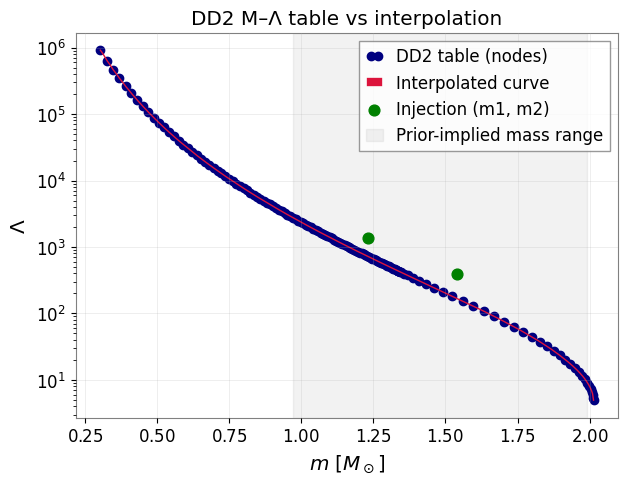

In [36]:
import numpy as np
import matplotlib.pyplot as plt

m_check = np.linspace(np.asarray(dd2_m_grid).min(), np.asarray(dd2_m_grid).max(), 500)
lambda_check = np.interp(m_check, np.asarray(dd2_m_grid), np.asarray(dd2_lambda_grid))

plt.figure(figsize=(7,5))
plt.plot(np.asarray(dd2_m_grid), np.asarray(dd2_lambda_grid), 'o', color='navy', label="DD2 table (nodes)")
plt.plot(m_check, lambda_check, '-', color='crimson', lw=1, label="Interpolated curve")
plt.scatter([1.54, 1.232], [391.0560048763879, 1383.665429681563],
            color='green', zorder=5, s=60, label="Injection (m1, m2)")
plt.axvspan(0.97, 1.99, color='gray', alpha=0.1, label="Prior-implied mass range")
plt.xlabel(r"$m\ [M_\odot]$"); plt.ylabel(r"$\Lambda$")
plt.legend(); plt.grid(alpha=0.3)
plt.title("DD2 M–Λ table vs interpolation")
plt.yscale("log")
plt.show()

In [37]:
 likelihood_transforms =[
    MassRatioToSymmetricMassRatioTransform,
    eos_transform_dd2,
    # reverse_bijective_transform(
    #     GeocentricArrivalTimeToDetectorArrivalTimeTransform(
    #         trigger_time=gps, ifo=ifos[0]
    #     )
    # ),
]

In [38]:
import jimgw
import jimgw.samplers
import os

print(jimgw.samplers.__path__)

['/usr/local/lib/python3.12/dist-packages/jimgw/samplers']


In [39]:
ls -R /usr/local/lib/python3.12/dist-packages/jimgw/samplers

/usr/local/lib/python3.12/dist-packages/jimgw/samplers:
base.py    config.py  __init__.py  __pycache__/
blackjax/  flowmc.py  periodic.py

/usr/local/lib/python3.12/dist-packages/jimgw/samplers/blackjax:
_acceptance_walk_kernel.py  __init__.py  nss.py        smc.py
_imports.py                 ns_aw.py     __pycache__/

/usr/local/lib/python3.12/dist-packages/jimgw/samplers/blackjax/__pycache__:
_acceptance_walk_kernel.cpython-312.pyc  ns_aw.cpython-312.pyc
_imports.cpython-312.pyc                 nss.cpython-312.pyc
__init__.cpython-312.pyc                 smc.cpython-312.pyc

/usr/local/lib/python3.12/dist-packages/jimgw/samplers/__pycache__:
base.cpython-312.pyc    flowmc.cpython-312.pyc    periodic.cpython-312.pyc
config.cpython-312.pyc  __init__.cpython-312.pyc


In [40]:
# import inspect
# from jimgw.core.jim import Jim
# from jimgw.core.single_event.likelihood import TransientLikelihoodFD

# print(inspect.getsource(Jim._validate_problem))   # see exactly what "provided" is computed from
# print(inspect.signature(TransientLikelihoodFD.__init__))

In [41]:
 # confirm all 7 keys are actually there before building Jim

--- Likelihood ---

In [42]:
fixed_parameters = {
    #"M_c": inj_params["M_c"],
   # "d_L": inj_params["d_L"],
   # "iota": inj_params["iota"],
   # "t_c": inj_params["t_c"],
   # "psi": inj_params["psi"],
    "ra": inj_params["ra"],
    "dec": inj_params["dec"],
}



In [43]:
import jax.numpy as jnp
from jimgw.core.single_event.likelihood import HeterodynedTransientLikelihoodFD

def _compute_coefficients_sparse(data, h_ref, psd, freqs, f_bins, f_bins_center):
    df = freqs[1] - freqs[0]
    data_prod = jnp.array(data * h_ref.conj()) / psd
    self_prod = jnp.array(h_ref * h_ref.conj()) / psd
    n_bins = f_bins_center.shape[0]
    bin_idx = jnp.clip(jnp.searchsorted(f_bins, freqs, side="right") - 1, 0, n_bins - 1)
    bin_idx = jnp.where(freqs == f_bins[-1], n_bins - 1, bin_idx)
    freq_shift = freqs - f_bins_center[bin_idx]

    def scatter_sum(values):
        return jnp.zeros((n_bins,), dtype=values.dtype).at[bin_idx].add(values)

    A0_array = 4 * scatter_sum(data_prod) * df
    A1_array = 4 * scatter_sum(data_prod * freq_shift) * df
    B0_array = 4 * scatter_sum(self_prod) * df
    B1_array = 4 * scatter_sum(self_prod * freq_shift) * df
    return A0_array, A1_array, B0_array, B1_array

HeterodynedTransientLikelihoodFD.compute_coefficients = staticmethod(_compute_coefficients_sparse)

In [44]:
import jax.numpy as jnp

def _isin_sparse(element, test_elements, **kwargs):
    """Drop-in replacement for jnp.isin(element, test_elements) when `element`
    is sorted and `test_elements` is an exact subset of it (true here, since
    self.frequencies is built as the union of all detectors' frequency grids).
    O(n) memory instead of O(len(element) * len(test_elements))."""
    element = jnp.asarray(element)
    test_elements = jnp.asarray(test_elements)
    idx = jnp.searchsorted(element, test_elements)
    idx = jnp.clip(idx, 0, element.shape[0] - 1)
    return jnp.zeros(element.shape[0], dtype=bool).at[idx].set(True)

jnp.isin = _isin_sparse

In [45]:
likelihood_het = HeterodynedTransientLikelihoodFD(
    ifos, waveform=waveform, trigger_time=gps, f_min=fmin, f_max=fmax,
    fixed_parameters=fixed_parameters,
    reference_parameters=inj_params,   # or the posterior median, either is reasonable here
   # phase_marginalization=True,
)


INFO | jimgw.core.single_event.likelihood | Initializing heterodyned likelihood..
INFO | jimgw.core.single_event.likelihood | Reference parameters provided, which are {'M_c': 1.1976232319088198, 'eta': 0.24691358024691357, 's1_z': 0.028327, 's2_z': 0.013249, 'd_L': 42.0, 'lambda_1': 391.0560048763879, 'lambda_2': 1383.665429681563, 't_c': -0.000236, 'phase_c': 2.0, 'iota': 2.8495, 'psi': 0.7, 'ra': 3.4396, 'dec': -0.3998}
INFO | jimgw.core.single_event.likelihood | Constructing reference waveforms..


--- Sample ---

In [46]:
SEED = 1

jim = Jim(
    #likelihood,
    likelihood_het,
    prior,
    sample_transforms=sample_transforms,
    likelihood_transforms=likelihood_transforms,
   # periodic=["psi_unit", "azimuth_unit"],
    periodic=["psi_unit","phase_c_unit"],
    sampler_config=BlackJAXNSAWConfig(
        n_live=500,
        n_delete_frac=0.25,
        n_target=80,
    ),
)

INFO | jimgw.core.jim | Using sample transforms.


In [47]:

jim._rng_key, jim._sampler_key = jax.random.split(jax.random.key(SEED), 2)

In [48]:
print("SEED =", SEED)
print("rng key:", jim._rng_key)
print("sampler key:", jim._sampler_key)

# If you want to see the raw uint32 values:
print("rng key data:", jax.random.key_data(jim._rng_key))
print("sampler key data:", jax.random.key_data(jim._sampler_key))

SEED = 1
rng key: Array((), dtype=key<fry>) overlaying:
[ 507451445 1853169794]
sampler key: Array((), dtype=key<fry>) overlaying:
[1948878966 4237131848]
rng key data: [ 507451445 1853169794]
sampler key data: [1948878966 4237131848]


#Sample

In [49]:

start_time = time.time()
jim.sample()
end_time = time.time()
print(f"Sampling took {(end_time - start_time) / 60:.2f} mins")

Sampling took 15.82 mins


In [69]:
inj_full = dict(inj_params)
logL_at_injection = likelihood_het.evaluate(inj_full)
print("logL at injection:", logL_at_injection)

chains = jim.get_samples()
print("max logL sampler:", np.max(chains["log_likelihood"]))

logL at injection: 5626398.011160043
max logL sampler: 5616262.642329978


In [70]:
q_c = np.asarray(chains["q"]); eta_c = q_c/(1+q_c)**2
Mc_c = np.asarray(chains["M_c"]); M_c_tot = Mc_c/eta_c**0.6
root_c = np.sqrt(np.clip(1-4*eta_c, 0, None))
m1_c = 0.5*M_c_tot*(1+root_c); m2_c = 0.5*M_c_tot*(1-root_c)
chains["lambda_1"] = np.interp(m1_c, np.asarray(dd2_m_grid), np.asarray(dd2_lambda_grid))
chains["lambda_2"] = np.interp(m2_c, np.asarray(dd2_m_grid), np.asarray(dd2_lambda_grid))

In [71]:
import os
import numpy as np
import jax

# -----------------------------
# Samples
# -----------------------------
samples = jim.get_samples()
samples = {k: np.asarray(v) for k, v in samples.items()}

# -----------------------------
# Diagnostics
# -----------------------------
diagnostics = jim.get_diagnostics()

# -----------------------------
# RNG keys
# -----------------------------
rng_key = jax.random.key_data(jim._rng_key)
sampler_key = jax.random.key_data(jim._sampler_key)

# -----------------------------
# Automatic filename
# -----------------------------
filename = (
    f"dL=42_Lambda_sfHo_correct_duration=8192_IMRPHENOMD_ET3+2CE_GN_Het_gauss_dl_iota_Nested_fmax=2048_nlive=500_phic_Injection_NSAW_"
    f"rng_{rng_key[0]}_{rng_key[1]}_"
    f"logZ_{diagnostics['log_Z']:.2f}.npz"
)

counter = 1
base = filename[:-4]
while os.path.exists(filename):
    filename = f"{base}_{counter}.npz"
    counter += 1

# -----------------------------
# Save everything
# -----------------------------
np.savez_compressed(
    filename,
    **samples,
    rng_key=rng_key,
    sampler_key=sampler_key,
    logZ=diagnostics["log_Z"],
    logZ_error=diagnostics["log_Z_error"],
    n_likelihood_evaluations=diagnostics["n_likelihood_evaluations"],
)

print(f"Saved to: {filename}")

Saved to: dL=42_Lambda_sfHo_correct_duration=8192_IMRPHENOMD_ET3+2CE_GN_Het_gauss_dl_iota_Nested_fmax=2048_nlive=500_phic_Injection_NSAW_rng_3704974950_1863054868_logZ_5616206.68.npz


In [72]:
print("logZ:", diagnostics["log_Z"], diagnostics["log_Z_error"])
print("max logL:", np.max(samples["log_likelihood"]))
print("median logL:", np.median(samples["log_likelihood"]))

logZ: 5616206.677215133 0.31992063585432273
max logL: 5616262.642329978
median logL: 5616258.722250346


In [54]:
print(jim.__dict__.keys())

dict_keys(['likelihood', 'prior', 'sample_transforms', 'likelihood_transforms', 'parameter_names', '_log_prior_fn', '_log_likelihood_fn', '_log_posterior_fn', '_rng_key', '_sampler_key', '_sampler_config', 'sampler'])


In [73]:
print(jim._rng_key)
print(jim._sampler_key)

Array((), dtype=key<fry>) overlaying:
[3704974950 1863054868]
Array((), dtype=key<fry>) overlaying:
[1948878966 4237131848]


--- Results ---

In [74]:
diagnostics = jim.get_diagnostics()
print(f"log Z = {diagnostics['log_Z']:.2f} ± {diagnostics['log_Z_error']:.2f}")
print(f"Likelihood evaluations: {diagnostics['n_likelihood_evaluations']:,}")

log Z = 5616206.68 ± 0.35
Likelihood evaluations: 32,692,401


q_inj (from injected eta): 0.7999999999999996


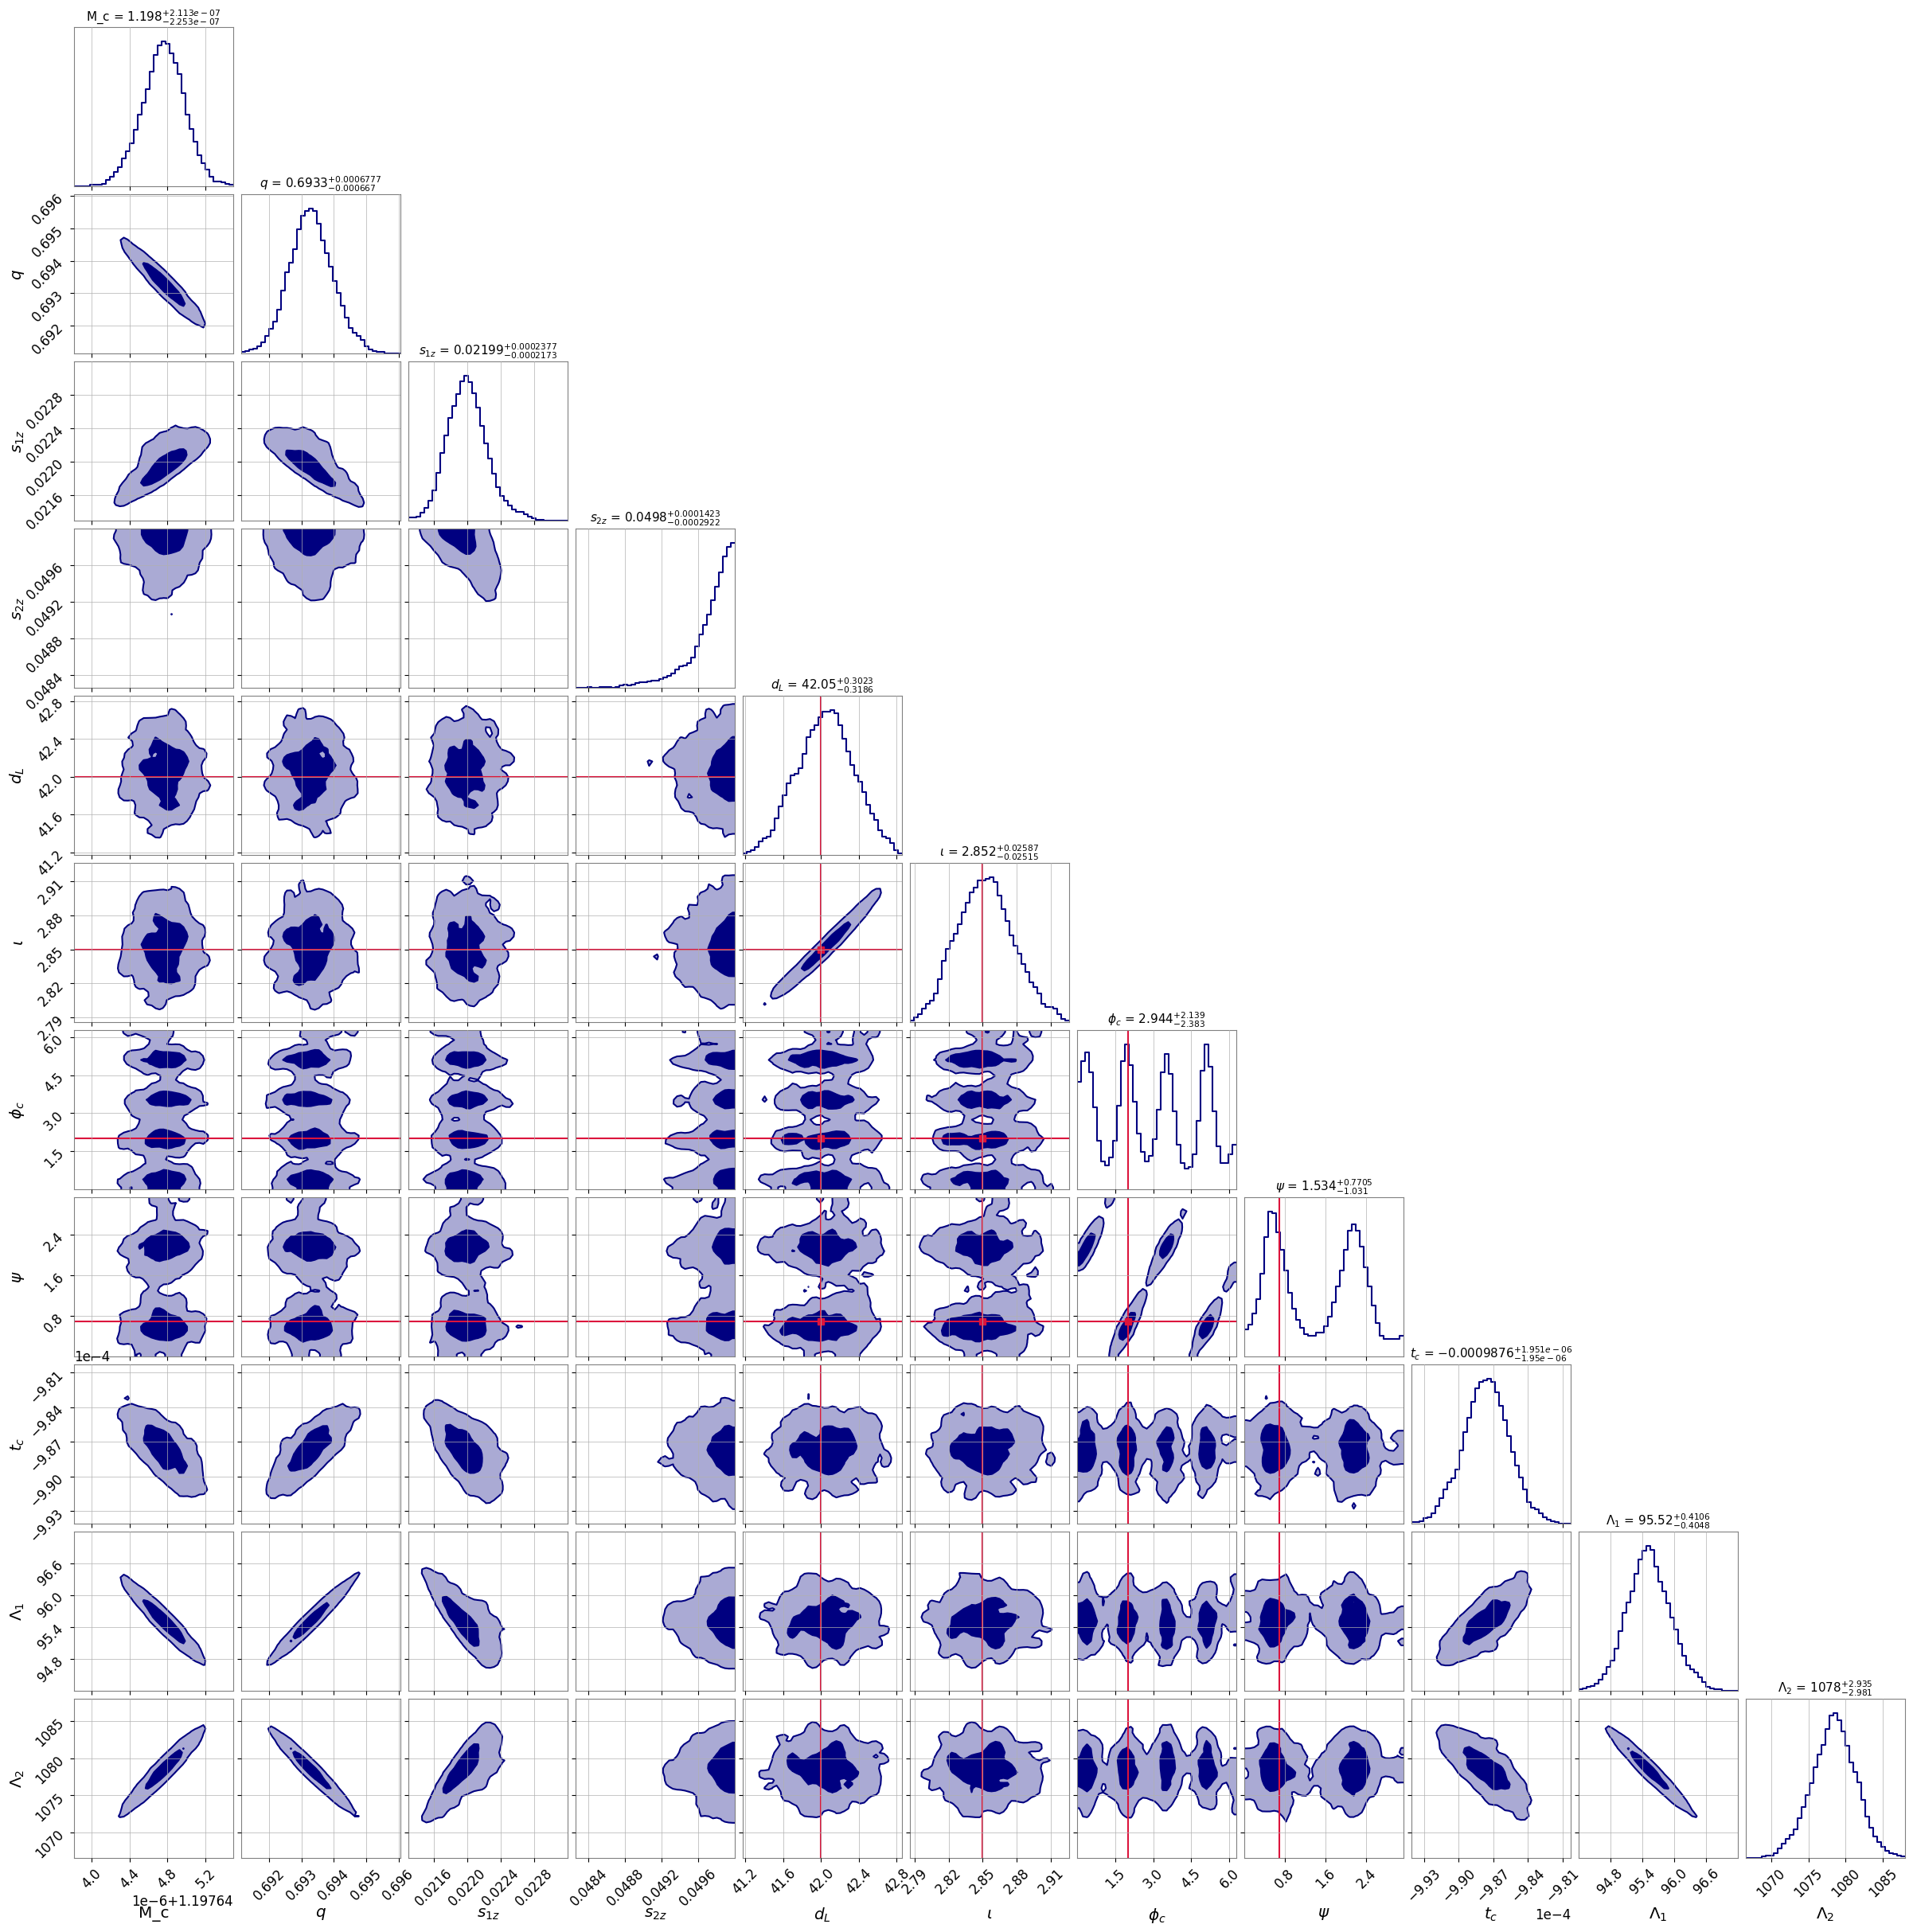

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import corner

def eta_to_q(eta):
    """Invert eta = q/(1+q)^2 for q in (0,1]."""
    return ((1 - 2*eta) - np.sqrt(1 - 4*eta)) / (2*eta)

q_inj = eta_to_q(inj_params["eta"])
print("q_inj (from injected eta):", q_inj)   # ~0.639, not 0.8


params = ["M_c","q", "s1_z", "s2_z","d_L","iota","phase_c","psi","t_c","lambda_1","lambda_2"]
labels = [
   r"M_c", r"$q$", r"$s_{1z}$", r"$s_{2z}$",r"$d_L$",r"$\iota$",r"$\phi_c$",r"$\psi$",r"$t_c$",r"$\Lambda_1$",r"$\Lambda_2$"

]
truths = [
    inj_params["M_c"],
    q_inj,
    inj_params["s1_z"],
    inj_params["s2_z"],
    inj_params["d_L"],
    inj_params["iota"],
    inj_params["phase_c"],
    inj_params["psi"],
    inj_params["t_c"],
    inj_params["lambda_1"],
    inj_params["lambda_2"],

]

samples = np.vstack([np.asarray(chains[p]) for p in params]).T

level_1sigma = 0.39346934
level_2sigma = 0.86466472
fig = corner.corner(
    samples,
    labels=labels,
    truths=truths,
    truth_color="crimson",
    levels=(level_1sigma, level_2sigma),
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    color="navy",
    hist_kwargs={"color": "navy", "linewidth": 1.5},
    truth_kwargs={"color": "crimson", "linewidth": 1.8, "linestyle": "--"},
    show_titles=True,
    title_fmt=".4g",
    title_kwargs={"fontsize": 11},
    smooth=1.0,
    smooth1d=1.0,
    bins=40,
)
plt.savefig("dL=42_lambda_sfHo_correct_duration=8192_IMRPHENOMD_ET3+2CE_GN_Het__gauss_dl_iota_nlive=500_phic_corner_injection_1sigma_2sigma.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
truths

[1.1976232319088198,
 np.float64(0.7999999999999996),
 0.028327,
 0.013249,
 42.0,
 2.8495,
 2.0,
 0.7,
 -0.000236,
 391.0560048763879,
 1383.665429681563]

In [77]:
import numpy as np

params = ["M_c", "q", "s1_z", "s2_z","d_L","iota","phase_c","psi","t_c"]

for p in params:
    x = np.asarray(chains[p])
    median = np.median(x)
    std = np.std(x, ddof=1)   # sample standard deviation
    print(f"{p:8s} median = {median:.6f}, std = {std:.6f}")

M_c      median = 1.197645, std = 0.000000
q        median = 0.693287, std = 0.000686
s1_z     median = 0.021991, std = 0.000243
s2_z     median = 0.049802, std = 0.000263
d_L      median = 42.051935, std = 0.298248
iota     median = 2.852106, std = 0.024726
phase_c  median = 2.943699, std = 1.807438
psi      median = 1.534273, std = 0.832717
t_c      median = -0.000988, std = 0.000002


In [78]:
for p, inj in [
    ("M_c", inj_params["M_c"]),
    ("q", q_inj),
    ("s1_z", inj_params["s1_z"]),
    ("s2_z", inj_params["s2_z"]),
    ("d_L", inj_params["d_L"]),
    ("iota", inj_params["iota"]),
    ("phase_c", inj_params["phase_c"]),
    ("psi", inj_params["psi"]),
    ("t_c", inj_params["t_c"]),
]:
    x = np.asarray(chains[p])
    perc = 100 * np.mean(x < inj)
    print(f"{p:6s}: injected value at {perc:.1f} percentile")

M_c   : injected value at 0.0 percentile
q     : injected value at 100.0 percentile
s1_z  : injected value at 100.0 percentile
s2_z  : injected value at 0.0 percentile
d_L   : injected value at 42.9 percentile
iota  : injected value at 46.6 percentile
phase_c: injected value at 37.4 percentile
psi   : injected value at 30.7 percentile
t_c   : injected value at 100.0 percentile


In [79]:
frequencies = ifos[0].data.frequencies

In [80]:
h_inj = waveform(frequencies, inj_params)   # inj_params already has 'eta' directly

median_params = dict(fixed_parameters)   # everything currently fixed, physical values

if "M_c" in chains:
    median_params["M_c"] = float(np.median(chains["M_c"]))
if "q" in chains:
    q_med = float(np.median(chains["q"]))
    median_params["eta"] = q_med / (1 + q_med) ** 2
if "s1_z" in chains:
    median_params["s1_z"] = float(np.median(chains["s1_z"]))
if "s2_z" in chains:
    median_params["s2_z"] = float(np.median(chains["s2_z"]))
if "d_L" in chains:
    median_params["d_L"] = float(np.median(chains["d_L"]))
if "iota" in chains:
    median_params["iota"] = float(np.median(chains["iota"]))
if "phase_c" in chains:
    median_params["phase_c"] = float(np.median(chains["phase_c"]))
else:
    median_params["phase_c"] = 0.0
if "lambda_1" in chains: median_params["lambda_1"] = float(np.median(chains["lambda_1"]))
if "lambda_2" in chains: median_params["lambda_2"] = float(np.median(chains["lambda_2"]))

h_med = waveform(frequencies, median_params)

/usr/local/lib/python3.12/dist-packages/gwpy/plot/axes.py:201: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(renderer)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


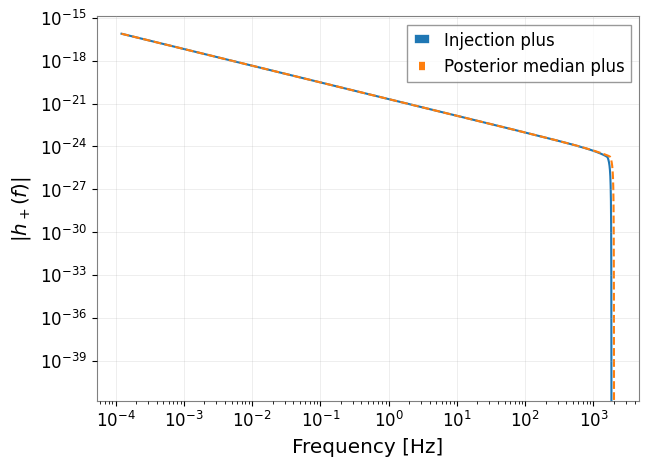

In [81]:
plt.figure(figsize=(7,5))

plt.loglog(frequencies, np.abs(h_inj["p"]), label="Injection plus")
plt.loglog(frequencies, np.abs(h_med["p"]), "--", label="Posterior median plus")

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|h_+(f)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

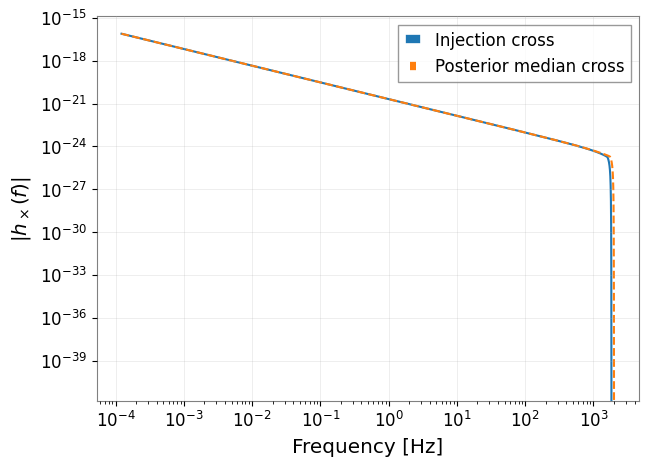

In [82]:
plt.figure(figsize=(7,5))

plt.loglog(frequencies, np.abs(h_inj["c"]), label="Injection cross")
plt.loglog(frequencies, np.abs(h_med["c"]), "--", label="Posterior median cross")

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|h_\times(f)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

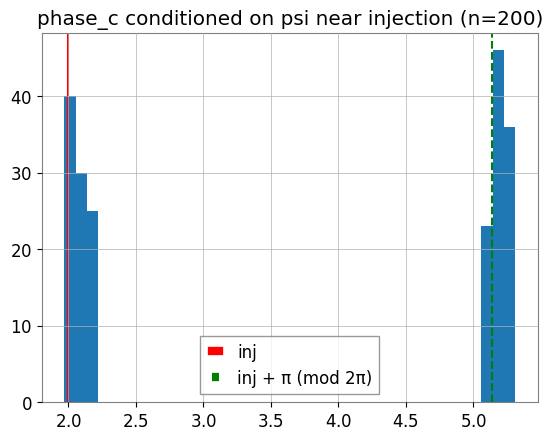

In [83]:
psi_inj = inj_params["psi"]
phase_c_inj = inj_params["phase_c"]
phase_c_alt = phase_c_inj + np.pi
psi_tol = 0.1  # radians
mask = np.abs(np.asarray(chains["psi"]) - psi_inj) < psi_tol
phase_c_near_psi_inj = np.asarray(chains["phase_c"])[mask]

plt.hist(phase_c_near_psi_inj, bins=40)
plt.axvline(phase_c_inj, color="r", label="inj")
plt.axvline(phase_c_alt, color="g", linestyle="--", label="inj + π (mod 2π)")
plt.legend()
plt.title(f"phase_c conditioned on psi near injection (n={mask.sum()})")
plt.show()

In [66]:
# import jax
# import jax.numpy as jnp
# import numpy as np

# samples = chains
# samples = {k: np.asarray(v) for k, v in samples.items()}
# n_check = 50
# idx = np.random.choice(len(samples["M_c"]), n_check, replace=False)

# def mass_ratio_to_eta(q):
#     return q / (1 + q) ** 2

# p_batch = {k: jnp.asarray(v[idx]) for k, v in samples.items() if k not in ("log_likelihood", "log_prior", "q")}
# p_batch["eta"] = mass_ratio_to_eta(jnp.asarray(samples["q"][idx]))
# for k, v in fixed_parameters.items():
#     p_batch[k] = jnp.full(n_check, v)  # broadcast fixed params to match batch dim

# eval_full_jit = jax.jit(jax.vmap(likelihood.evaluate))
# eval_het_jit = jax.jit(jax.vmap(likelihood_het.evaluate))

# logL_full = eval_full_jit(p_batch)
# logL_het = eval_het_jit(p_batch)

# diffs = np.asarray(logL_full) - np.asarray(logL_het)
# print("max |diff|:", np.abs(diffs).max(), " mean:", diffs.mean(), " std:", diffs.std())

In [67]:
import jimgw.core.prior as prior_module
print([x for x in dir(prior_module) if any(s in x for s in ("Gauss", "Normal", "Truncated"))])

['GaussianPrior', 'StandardNormalDistribution']


In [68]:
import inspect
from jimgw.core.prior import GaussianPrior, StandardNormalDistribution

print(inspect.getsource(GaussianPrior))
print("=" * 80)
print(inspect.getsource(StandardNormalDistribution))

@jaxtyped(typechecker=typechecker)
class GaussianPrior(SequentialTransformPrior):
    """Gaussian (normal) prior with specified mean and standard deviation.

    Attributes:
        mu: Mean of the distribution.
        sigma: Standard deviation of the distribution.
    """

    mu: float
    sigma: float

    def __repr__(self):
        return f"GaussianPrior(mu={self.mu}, sigma={self.sigma}, parameter_names={self.parameter_names})"

    def __init__(
        self,
        mu: float,
        sigma: float,
        parameter_names: list[str],
    ):
        """
        Args:
            mu: Mean of the distribution.
            sigma: Standard deviation of the distribution.
            parameter_names: List with a single parameter name.
        """
        assert len(parameter_names) == 1, "GaussianPrior needs to be 1D distributions"
        assert sigma > 0, "sigma must be positive"
        self.mu = mu
        self.sigma = sigma
        super().__init__(
            [StandardNormalDis